In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.spectrum import log_bins, bin_midpoints, spectrum_from_function, normalise
from src.example_fields import moderated_field_pdf
from src.dose import load_coefficients
from src.uncertainty import propagate, summarise, sample_spectra, rebin

In [2]:
energies, coeffs = load_coefficients()
edges = log_bins(energies.min(), 20.0, 400)
phi = normalise(spectrum_from_function(edges, moderated_field_pdf))
mid = bin_midpoints(edges)

In [3]:
scenarios = {
    "A: 10% independent per bin": (0.10, 0.0),
    "B: 5% fully correlated": (0.0, 0.05),
    "C: both": (0.10, 0.05),
}
results = {name: propagate(edges, phi, b, a, energies, coeffs, n=10000)
           for name, (b, a) in scenarios.items()}

In [4]:
summarise(results["C: both"]).round(4)

,mean,std,rel_std_%,p2.5,p97.5
total_fluence,0.9997,0.0509,5.0944,0.8998,1.1002
mean_energy_MeV,1.0685,0.0119,1.1097,1.0453,1.0915
dose_pSv,198.2548,10.3638,5.2275,177.8758,218.7620
avg_coefficient_pSv_cm2,198.3146,1.6081,0.8109,195.0759,201.4116
dose_thermal_pSv,2.1288,0.1113,5.2304,1.9116,2.3495
dose_epithermal_pSv,4.7493,0.2453,5.1654,4.2746,5.2350
dose_fast_pSv,191.3766,10.0299,5.2409,171.5969,211.2273


In [5]:
rows = []
for name, res in results.items():
    s = summarise(res)
    rows.append({
        "scenario": name,
        "dose rel. std (%)": s.loc["dose_pSv", "rel_std_%"],
        "mean energy rel. std (%)": s.loc["mean_energy_MeV", "rel_std_%"],
        "avg coefficient rel. std (%)": s.loc["avg_coefficient_pSv_cm2", "rel_std_%"],
    })
pd.DataFrame(rows).round(2)

,scenario,dose rel. std (%),mean energy rel. std (%),avg coefficient rel. std (%)
0,A: 10% independent per bin,1.43,1.11,0.81
1,B: 5% fully correlated,5.03,0.00,0.00
2,C: both,5.23,1.11,0.81


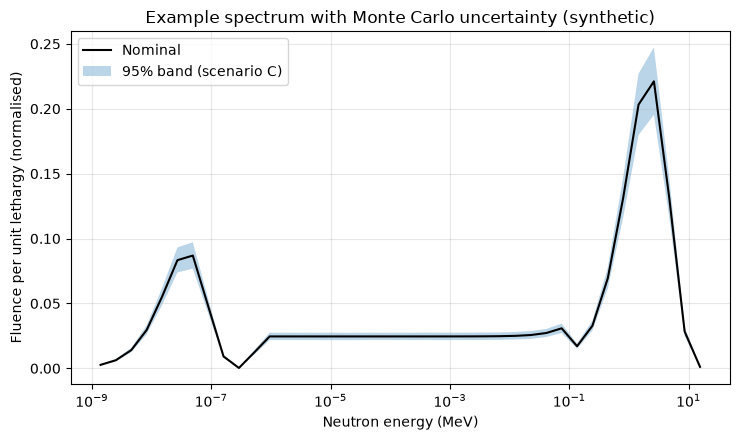

In [6]:
samples = sample_spectra(phi, 0.10, 0.05, n=5000, seed=1)
coarse_edges = log_bins(edges[0], edges[-1], 40)
coarse_samples = rebin(samples, edges, coarse_edges)
coarse_nominal = rebin(phi, edges, coarse_edges)
coarse_mid = bin_midpoints(coarse_edges)
dln = np.log(coarse_edges[1:] / coarse_edges[:-1])
lo, hi = np.percentile(coarse_samples, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogx(coarse_mid, coarse_nominal / dln, "k-", label="Nominal")
ax.fill_between(coarse_mid, lo / dln, hi / dln, alpha=0.3, label="95% band (scenario C)")
ax.set_xlabel("Neutron energy (MeV)")
ax.set_ylabel("Fluence per unit lethargy (normalised)")
ax.set_title("Example spectrum with Monte Carlo uncertainty (synthetic)")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig("../figures/spectrum_uncertainty_band.png", dpi=300)
plt.show()

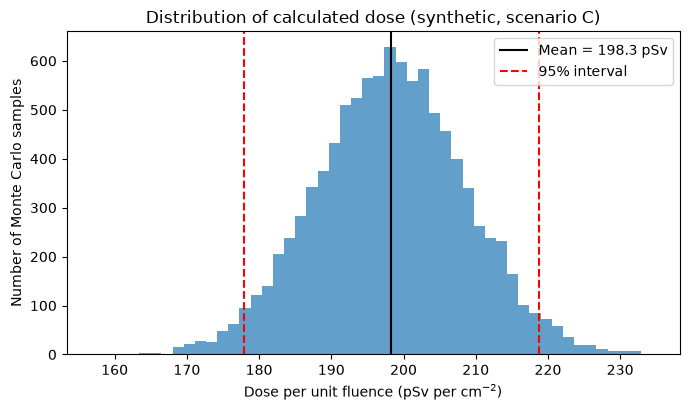

In [7]:
dose = results["C: both"]["dose_pSv"]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(dose, bins=50, alpha=0.7)
ax.axvline(dose.mean(), color="k", label=f"Mean = {dose.mean():.1f} pSv")
ax.axvline(np.percentile(dose, 2.5), color="r", linestyle="--", label="95% interval")
ax.axvline(np.percentile(dose, 97.5), color="r", linestyle="--")
ax.set_xlabel("Dose per unit fluence (pSv per cm$^{-2}$)")
ax.set_ylabel("Number of Monte Carlo samples")
ax.set_title("Distribution of calculated dose (synthetic, scenario C)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/dose_distribution.png", dpi=300)
plt.show()

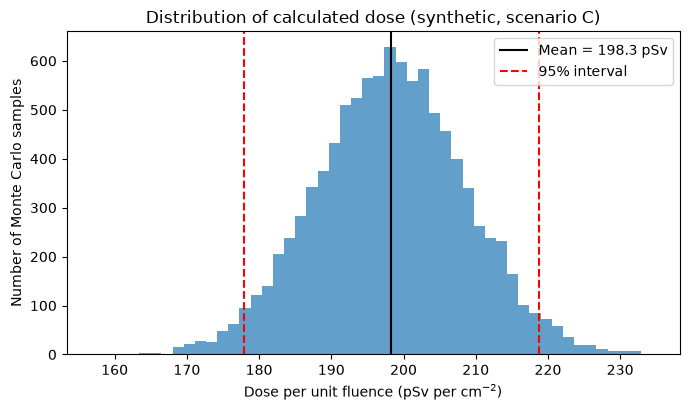

In [8]:
dose = results["C: both"]["dose_pSv"]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(dose, bins=50, alpha=0.7)
ax.axvline(dose.mean(), color="k", label=f"Mean = {dose.mean():.1f} pSv")
ax.axvline(np.percentile(dose, 2.5), color="r", linestyle="--", label="95% interval")
ax.axvline(np.percentile(dose, 97.5), color="r", linestyle="--")
ax.set_xlabel("Dose per unit fluence (pSv per cm$^{-2}$)")
ax.set_ylabel("Number of Monte Carlo samples")
ax.set_title("Distribution of calculated dose (synthetic, scenario C)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/dose_distribution.png", dpi=300)
plt.show()

In [9]:
print("Total fluence before rebinning:", phi.sum())
print("Total fluence after rebinning: ", coarse_nominal.sum())

Total fluence before rebinning: 1.0
Total fluence after rebinning:  1.0


In [72]:
#interpretation